# Machine Learning from Examples — Live Coding Introduction

This notebook accompanies an introductory lecture on Machine Learning based on ideas from **Chapter 19 of *Artificial Intelligence: A Modern Approach***.

Goals of this session:
- Understand what machine learning is
- Distinguish supervised and unsupervised learning
- Demonstrate core concepts through small visual examples

We will explore:
1. Train/Test split
2. Overfitting in regression
3. Decision trees for classification
4. K-means clustering
5. Learning curves


In [1]:
# numerical computation - basically vector,matrix, tensor operation
import numpy as np
# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# we will utilize scikit-learn library
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression, make_blobs
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.model_selection import learning_curve

sns.set(style='whitegrid')

## 1. What is Machine Learning?

Machine learning allows computers to **learn patterns from data instead of following explicitly programmed rules**.

### Types of Machine Learning

**Supervised Learning**
- Regression
- Classification

**Unsupervised Learning**
- Clustering


## 2. Train/Test Split

- **Training set**: used to train the model
- **Test set**: used to evaluate the model

Evaluating on training data alone can lead to overly optimistic results.

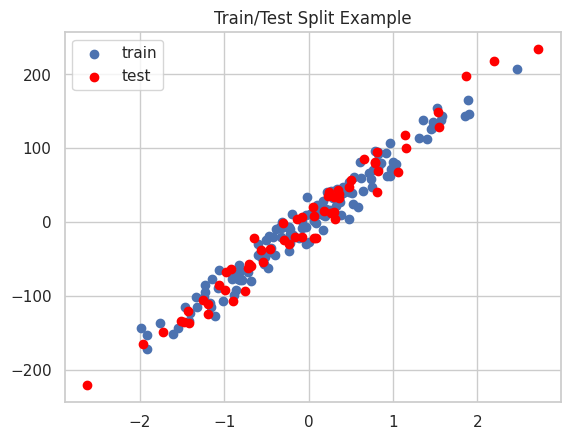

In [2]:
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# so we split our data into 70 percent train and 30 percent test
# typical range is 70 to 90 for training and according 30 to 10 for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
# while I do have a notebook on doing split yourself
# generally you want to let the library handle the split

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test', color='red')
plt.title('Train/Test Split Example')
plt.legend()
plt.show()

## 3. Overfitting in Regression

**Underfitting**: model too simple

**Overfitting**: model memorizes noise in the data

Goal: balance **bias and variance**.

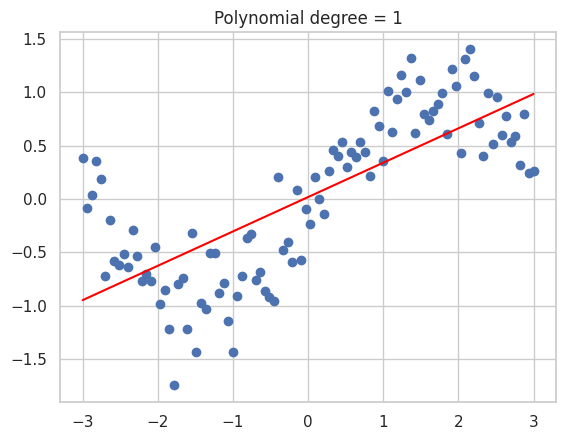

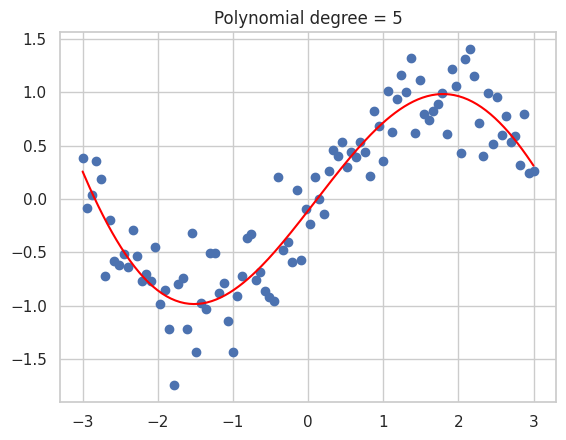

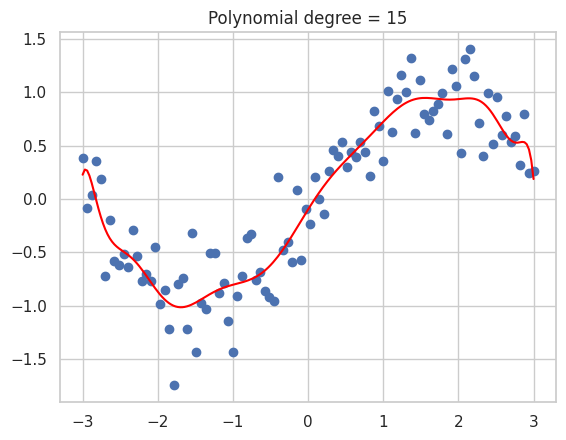

In [3]:
np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1,1)
# so here we are all knowing Creature we know the function used
# but in REAL LIFE we would not know this...
y = np.sin(X) + np.random.normal(0, 0.3, size=X.shape)

def fit_and_plot(degree):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)

    X_plot = np.linspace(-3,3,200).reshape(-1,1)
    X_plot_poly = poly.transform(X_plot)
    y_pred = model.predict(X_plot_poly)

    plt.scatter(X, y)
    plt.plot(X_plot, y_pred, color='red')
    plt.title(f'Polynomial degree = {degree}')
    plt.show()

fit_and_plot(1)
fit_and_plot(5)
fit_and_plot(15)

In [ ]:
# think what will happend when we supply some new data outside the range of existing data....

## 4. Decision Trees for Classification

Decision trees learn **IF/THEN rules** based on the data.

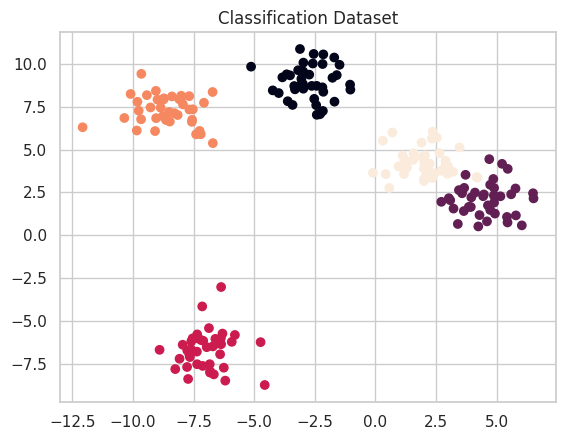

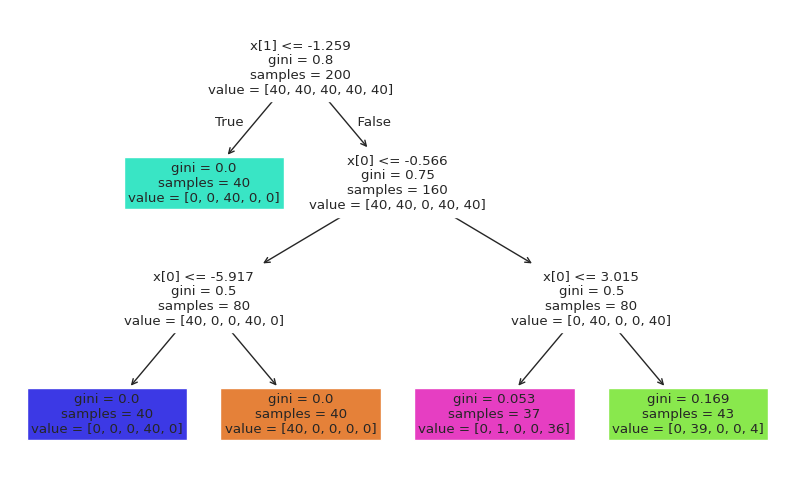

In [8]:
# again our incoming data was very simple we simply supply two blobs
X, y = make_blobs(n_samples=200, centers=5, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title('Classification Dataset')
plt.show()

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

plt.figure(figsize=(10,6))
plot_tree(tree, filled=True)
plt.show()

## 5. K-Means Clustering

Clustering discovers structure **without labels**.

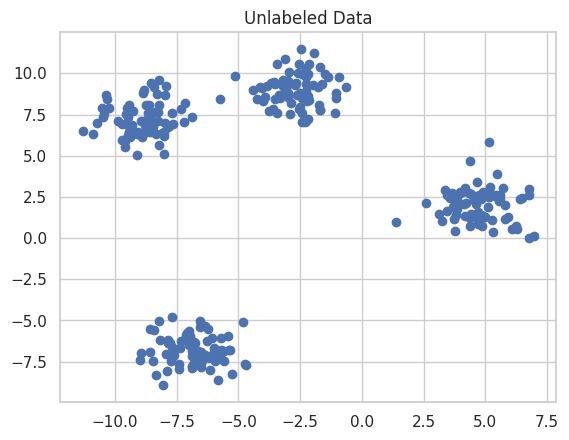

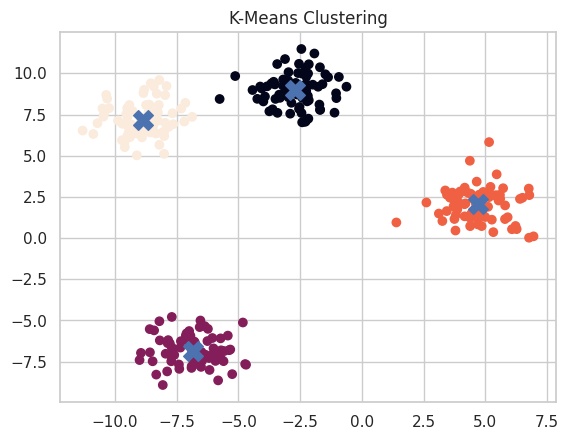

In [13]:
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

plt.scatter(X[:,0], X[:,1])
plt.title('Unlabeled Data')
plt.show()

# K-means works pretty good if we KNOW how many clusters we expect
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.title('K-Means Clustering')
plt.show()

## Summary

Key ideas demonstrated:
- Machine learning learns patterns from data
- Supervised vs unsupervised learning
- Train/test split
- Overfitting
- Decision trees
- K-means clustering
